# Descrição do Dataset: [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic/data)

O dataset utilizado nesta competição é uma versão derivativa e sintética que simula um cenário de ficção científica: o objetivo é prever se um passageiro foi transportado para uma dimensão alternativa após a colisão da nave ***Spaceship Titanic*** com uma anomalia espaço-temporal.

Para construir as previsões, o conjunto de dados fornece registros pessoais recuperados do sistema de computadores danificado da nave.

## Arquivos do Projeto

* **`train.csv`**: Registros pessoais de aproximadamente dois terços (~8.700) dos passageiros, utilizados como dados de treino. Contém a variável alvo (`Transported`).
* **`test.csv`**: Registros pessoais do terço restante (~4.300) dos passageiros, utilizados como dados de teste. O objetivo é prever o valor de `Transported` para este conjunto.

---

## Dicionário de Dados (Variáveis)

O conjunto de dados possui as seguintes colunas informativas:

## Identificação e Perfil do Passageiro

* **`PassengerId`**: Um identificador único para cada passageiro no formato `gggg_pp`, onde:
* `gggg` indica o grupo com o qual o passageiro está viajando (frequentemente membros da mesma família).
* `pp` é o número do passageiro dentro daquele grupo.

* **`Name`**: O nome e sobrenome do passageiro.
* **`Age`**: A idade do passageiro.

## Detalhes da Viagem

* **`HomePlanet`**: O planeta de origem do passageiro.
* **`Destination`**: O planeta de destino onde o passageiro iria desembarcar.
* **`Cabin`**: O número da cabine onde o passageiro estava hospedado. Segue o formato `deck/num/side` (conves/número/lado), onde o lado pode ser **P** (*Port* - Bombordo) ou **S** (*Starboard* - Estibordo).
* **`CryoSleep`**: Indica se o passageiro optou por ser colocado em animação suspensa (criossono) durante a viagem. Passageiros em criossono ficam confinados em suas cabines.
* **`VIP`**: Indica se o passageiro pagou por serviços VIP especiais durante a viagem.

## Despesas a Bordo

Valor total que o passageiro gastou em cada uma das muitas comodidades de luxo da Spaceship Titanic:

* **`RoomService`**: Serviço de quarto.
* **`FoodCourt`**: Praça de alimentação.
* **`ShoppingMall`**: Shopping center.
* **`Spa`**: Centro de relaxamento/Spa.
* **`VRDeck`**: Deck de Realidade Virtual.

## Variável Alvo (*Target*)

* **`Transported`**: Indica se o passageiro foi transportado para outra dimensão (**True** ou **False**). Esta é a variável que o modelo deve prever.

# *Setup* do ambiente

Nessa seção iremos:
- Baixar as bibliotecas necessárias no projeto;
- Definir configurações globais de bibliotecas;
- Baixar o dataset.

In [328]:
# Manipulação básica de dados
import pandas as pd

# Bibliotecas de visualização e utilitários usados nas células de EDA abaixo
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e modelagem
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Plot da arvore de decisao (metodo do scikit-learn)
from matplotlib_inline.backend_inline import set_matplotlib_formats
from sklearn import tree

# Estilo consistente para todos os gráficos
sns.set_theme(style="whitegrid")

In [329]:
train = pd.read_csv("./data/train.csv")
test = pd.read_csv("./data/test.csv")

print("Tabela com as primeiras linhas do conjunto de treino")

# Visualização rápida das primeiras linhas
train.head()

Tabela com as primeiras linhas do conjunto de treino


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# Análise Exploratória dos Dados (EDA)

Nesta seção, a exploração foi reorganizada para responder perguntas de modelagem em uma ordem mais natural: primeiro entendemos o dataset, depois avaliamos qualidade dos dados, relações com o alvo e hipóteses de engenharia de atributos.

Para a EDA, criaremos uma cópia enriquecida do treino com `PassengerGroup`, `PassengerNum`, `CabinDeck`, `CabinNum`, `CabinSide`, `FamilyName` e `TotalSpend`. A mesma função será reaproveitada no pré-processamento para evitar divergência entre análise e modelagem.


In [330]:
# Pré-processamento pontual para simplificar a EDA e reaproveitar na modelagem
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
target = "Transported"

def split_cabin_passenger(df):
    out = df.copy()

    if "PassengerId" in out.columns:
        passenger_parts = out["PassengerId"].str.split("_", expand=True)
        out["PassengerGroup"] = passenger_parts[0]
        out["PassengerNum"] = pd.to_numeric(passenger_parts[1], errors="coerce")

    if "Cabin" in out.columns:
        cabin_parts = out["Cabin"].str.split("/", expand=True)
        out["CabinDeck"] = cabin_parts[0]
        out["CabinNum"] = pd.to_numeric(cabin_parts[1], errors="coerce")
        out["CabinSide"] = cabin_parts[2]

    if "Name" in out.columns:
        out["FamilyName"] = out["Name"].str.strip().str.rsplit(" ", n=1).str[-1]

    available_spend_cols = [col for col in spend_cols if col in out.columns]
    if available_spend_cols:
        out["TotalSpend"] = out[available_spend_cols].sum(axis=1, min_count=1)

    out = out.drop(columns=["PassengerId", "Cabin", "Name"], errors="ignore")
    return out

eda = split_cabin_passenger(train)
eda_test = split_cabin_passenger(test)

# Variáveis auxiliares usadas apenas nas análises exploratórias.
eda["SpentSomething"] = eda[spend_cols].gt(0).any(axis=1)
eda["HasMissingSpend"] = eda[spend_cols].isna().any(axis=1)

print("Prévia das variáveis derivadas para a EDA")
display(
    eda[[
        "PassengerGroup",
        "PassengerNum",
        "FamilyName",
        "CabinDeck",
        "CabinNum",
        "CabinSide",
        "TotalSpend",
        "SpentSomething",
    ]].head()
)


Prévia das variáveis derivadas para a EDA


,PassengerGroup,PassengerNum,FamilyName,CabinDeck,CabinNum,CabinSide,TotalSpend,SpentSomething
0,0001,1,Ofracculy,B,0.0,P,0.0,False
1,0002,1,Vines,F,0.0,S,736.0,True
2,0003,1,Susent,A,0.0,S,10383.0,True
3,0003,2,Susent,A,0.0,S,5176.0,True
4,0004,1,Santantines,F,1.0,S,1091.0,True


## 1. Entendimento básico do dataset

Esta primeira parte estabelece o tamanho da base, os tipos de dados, estatísticas descritivas e o balanceamento do alvo `Transported`. Essa visão evita que as próximas análises fiquem soltas: antes de procurar padrões, precisamos saber a escala e a composição dos dados.


In [331]:
# Dimensões e tipos principais
overview = pd.DataFrame(
    {
        "dataset": ["train bruto", "test bruto", "train EDA"],
        "linhas": [train.shape[0], test.shape[0], eda.shape[0]],
        "colunas": [train.shape[1], test.shape[1], eda.shape[1]],
    }
)

print("Dimensões dos datasets")
display(overview)

print("Info do treino bruto")
train.info()

print("Info do treino enriquecido para EDA")
eda.info()


Dimensões dos datasets


,dataset,linhas,colunas
0,train bruto,8693,14
1,test bruto,4277,13
2,train EDA,8693,20


Info do treino bruto
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB
Info do treino enriquecido para EDA
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 20 co

In [332]:
# Estatísticas descritivas numéricas e categóricas
print("Estatísticas descritivas das variáveis numéricas")
display(eda.describe(include=[np.number]).T.round(2))

print("Resumo das variáveis categóricas e booleanas")
categorical_summary = eda.select_dtypes(include=["str", "bool"]).describe().T
display(categorical_summary)


Estatísticas descritivas das variáveis numéricas


,count,mean,std,min,25%,50%,75%,max
Age,8514.0,28.83,14.49,0.0,19.00,27.0,38.0,79.0
RoomService,8512.0,224.69,666.72,0.0,0.00,0.0,47.0,14327.0
FoodCourt,8510.0,458.08,1611.49,0.0,0.00,0.0,76.0,29813.0
ShoppingMall,8485.0,173.73,604.70,0.0,0.00,0.0,27.0,23492.0
Spa,8510.0,311.14,1136.71,0.0,0.00,0.0,59.0,22408.0
VRDeck,8505.0,304.85,1145.72,0.0,0.00,0.0,46.0,24133.0
PassengerNum,8693.0,1.52,1.05,1.0,1.00,1.0,2.0,8.0
CabinNum,8494.0,600.37,511.87,0.0,167.25,427.0,999.0,1894.0
TotalSpend,8693.0,1440.87,2803.05,0.0,0.00,716.0,1441.0,35987.0


Resumo das variáveis categóricas e booleanas


,count,unique,top,freq
HomePlanet,8492,3,Earth,4602
Destination,8511,3,TRAPPIST-1e,5915
Transported,8693,2,True,4378
PassengerGroup,8693,6217,0984,8
CabinDeck,8494,8,F,2794
CabinSide,8494,2,S,4288
SpentSomething,8693,2,True,5040
HasMissingSpend,8693,2,False,7785


Tabela com contagem e percentual do atributo alvo


,count,pct
Transported,,
True,4378,50.36
False,4315,49.64


Gráfico com distribuição do atributo alvo


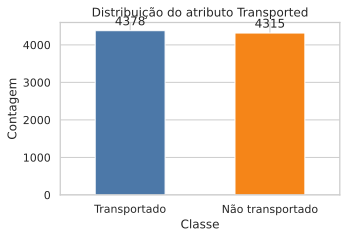

In [333]:
# Distribuição do atributo alvo para checar balanceamento de classes
target_counts = eda[target].value_counts(dropna=False).rename("count")
target_pct = eda[target].value_counts(normalize=True, dropna=False).mul(100).round(2).rename("pct")
target_summary = pd.concat([target_counts, target_pct], axis=1)

print("Tabela com contagem e percentual do atributo alvo")
display(target_summary)

print("Gráfico com distribuição do atributo alvo")
fig, ax = plt.subplots(figsize=(5, 3.5))
colors = ["#4C78A8", "#F58518"]
target_counts.rename(index={False: "Não transportado", True: "Transportado"}).plot(
    kind="bar",
    ax=ax,
    color=colors,
)
ax.set_title("Distribuição do atributo Transported")
ax.set_xlabel("Classe")
ax.set_ylabel("Contagem")
ax.bar_label(ax.containers[0], padding=3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 2. Valores ausentes

Aqui avaliamos tanto a quantidade de valores nulos quanto a quantidade de valores não nulos por atributo. Como os percentuais de ausência são pequenos, a escolha de imputação no pré-processamento pode ser simples, mas ainda precisa ser consistente entre treino e teste.


In [334]:
# Função auxiliar: resumo de valores nulos e não nulos por coluna
def missing_summary(df):
    missing = df.isna().sum()
    non_null = df.notna().sum()
    out = pd.DataFrame(
        {
            "non_null_count": non_null,
            "missing_count": missing,
            "missing_pct": (missing / len(df) * 100).round(2),
        }
    )
    return out.sort_values(["missing_count", "missing_pct"], ascending=False)

missing_eda = missing_summary(eda)
missing_test = missing_summary(eda_test)

print("Valores ausentes no treino")
display(missing_eda[missing_eda["missing_count"] > 0])

print("Valores ausentes no teste")
display(missing_test[missing_test["missing_count"] > 0])


Valores ausentes no treino


,non_null_count,missing_count,missing_pct
CryoSleep,8476,217,2.50
ShoppingMall,8485,208,2.39
VIP,8490,203,2.34
HomePlanet,8492,201,2.31
FamilyName,8493,200,2.30
CabinDeck,8494,199,2.29
CabinNum,8494,199,2.29
CabinSide,8494,199,2.29
VRDeck,8505,188,2.16
FoodCourt,8510,183,2.11


Valores ausentes no teste


,non_null_count,missing_count,missing_pct
FoodCourt,4171,106,2.48
Spa,4176,101,2.36
CabinDeck,4177,100,2.34
CabinNum,4177,100,2.34
CabinSide,4177,100,2.34
ShoppingMall,4179,98,2.29
FamilyName,4183,94,2.20
CryoSleep,4184,93,2.17
VIP,4184,93,2.17
Destination,4185,92,2.15


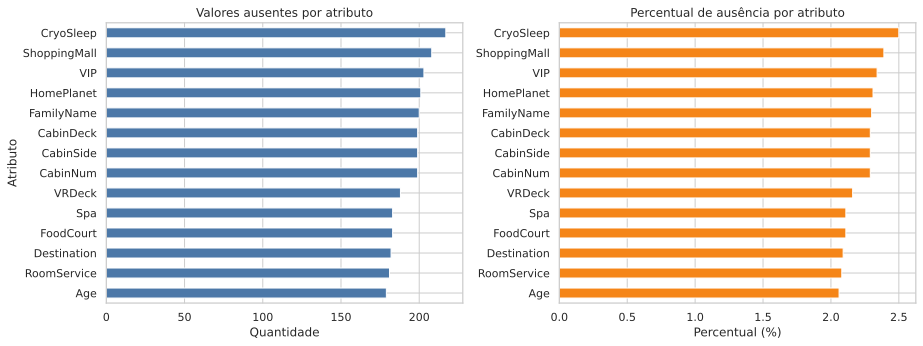

In [335]:
# Visualização da nulidade por atributo no treino
missing_to_plot = missing_eda[missing_eda["missing_count"] > 0].sort_values("missing_count")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

missing_to_plot["missing_count"].plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("Valores ausentes por atributo")
axes[0].set_xlabel("Quantidade")
axes[0].set_ylabel("Atributo")

missing_to_plot["missing_pct"].plot(kind="barh", ax=axes[1], color="#F58518")
axes[1].set_title("Percentual de ausência por atributo")
axes[1].set_xlabel("Percentual (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 3. Relações lógicas entre atributos e target

Nesta subseção, olhamos quais atributos se relacionam diretamente com `Transported`. Para variáveis categóricas de baixa cardinalidade, usamos taxa de transporte por categoria. Para variáveis numéricas, usamos correlação como uma primeira leitura linear, sem tratá-la como causalidade.


In [336]:
# Taxa de transporte por atributo categórico
def target_rate_by(df, col):
    summary = (
        df.groupby(col, dropna=False)[target]
        .agg(qtd_passageiros="count", taxa_transporte="mean")
        .sort_values("taxa_transporte", ascending=False)
    )
    summary["taxa_transporte_pct"] = (summary["taxa_transporte"] * 100).round(2)
    return summary.drop(columns="taxa_transporte")

categorical_rate_cols = ["HomePlanet", "Destination", "CryoSleep", "VIP", "CabinDeck", "CabinSide"]

for col in categorical_rate_cols:
    print(f"Taxa de transporte por {col}")
    display(target_rate_by(eda, col))


Taxa de transporte por HomePlanet


,qtd_passageiros,taxa_transporte_pct
HomePlanet,,
Europa,2131,65.88
Mars,1759,52.30
NaN,201,51.24
Earth,4602,42.39


Taxa de transporte por Destination


,qtd_passageiros,taxa_transporte_pct
Destination,,
55 Cancri e,1800,61.00
NaN,182,50.55
PSO J318.5-22,796,50.38
TRAPPIST-1e,5915,47.12


Taxa de transporte por CryoSleep


...

,qtd_passageiros,taxa_transporte_pct
VIP,,
NaN,203,51.23
False,8291,50.63
True,199,38.19


Taxa de transporte por CabinDeck


,qtd_passageiros,taxa_transporte_pct
CabinDeck,,
B,779,73.43
C,747,68.01
G,2559,51.62
NaN,199,50.25
A,256,49.61
F,2794,43.99
D,478,43.31
E,876,35.73
T,5,20.00


Taxa de transporte por CabinSide


,qtd_passageiros,taxa_transporte_pct
CabinSide,,
S,4288,55.50
NaN,199,50.25
P,4206,45.13


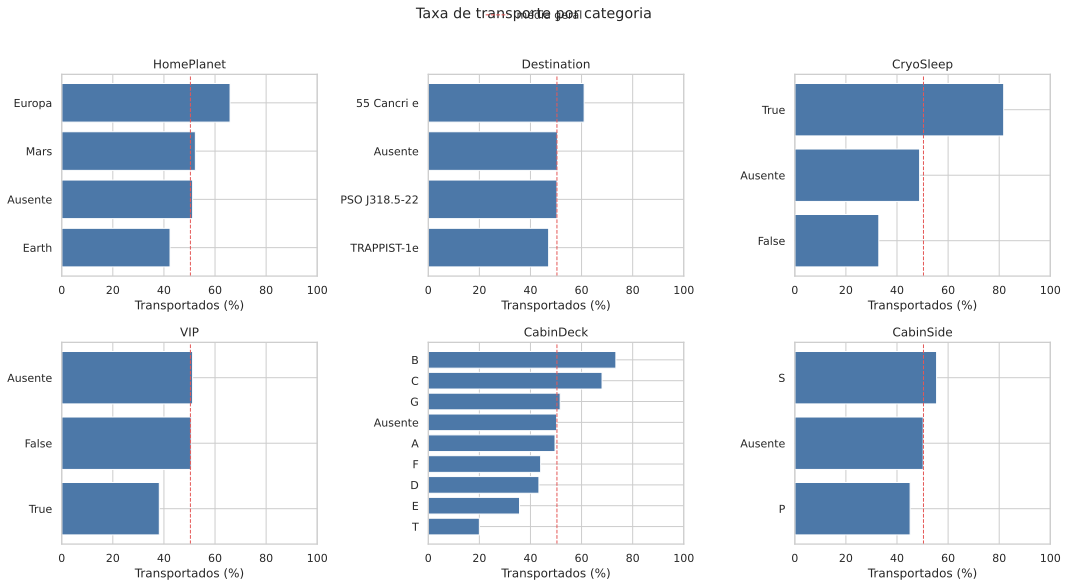

In [337]:
# Gráficos de taxa de transporte por categorias principais
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
base_rate = eda[target].mean() * 100

for ax, col in zip(axes.ravel(), categorical_rate_cols):
    rate = target_rate_by(eda, col).sort_values("taxa_transporte_pct")
    labels = ["Ausente" if pd.isna(value) else str(value) for value in rate.index]
    ax.barh(labels, rate["taxa_transporte_pct"].to_numpy(), color="#4C78A8")
    ax.axvline(base_rate, color="#E45756", linestyle="--", linewidth=1, label="média geral")
    ax.set_title(col)
    ax.set_xlabel("Transportados (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=1, frameon=False)
fig.suptitle("Taxa de transporte por categoria", y=1.02)
plt.tight_layout()
plt.show()


Correlação das variáveis numéricas com Transported


,corr_com_target
RoomService,-0.245
Spa,-0.221
VRDeck,-0.207
TotalSpend,-0.200
Age,-0.075
PassengerNum,0.066
FoodCourt,0.047
CabinNum,-0.045
ShoppingMall,0.010


Heatmap de correlações numéricas


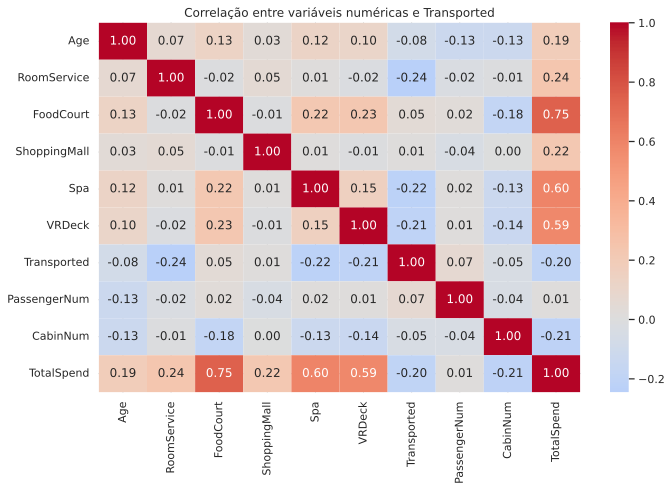

In [338]:
# Correlação numérica com o alvo e entre atributos numéricos
corr_data = eda.copy()
corr_data[target] = corr_data[target].astype(int)

numeric_cols_for_corr = corr_data.select_dtypes(include="number").columns
corr = corr_data[numeric_cols_for_corr].corr()

print("Correlação das variáveis numéricas com Transported")
target_corr = corr[target].drop(target).sort_values(key=lambda values: values.abs(), ascending=False)
display(target_corr.to_frame("corr_com_target").round(3))

print("Heatmap de correlações numéricas")
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlação entre variáveis numéricas e Transported")
plt.tight_layout()
plt.show()


## 4. Relações lógicas entre atributos de gastos e TotalSpend

As cinco colunas de gastos (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) são esparsas e com muitos zeros. Por isso, avaliamos `TotalSpend` como uma variável agregada. A pergunta prática para o pré-processamento é: podemos usar `TotalSpend` e remover as colunas individuais para reduzir redundância?


In [339]:
# Resumo dos gastos individuais e do gasto total
spend_summary = pd.DataFrame(
    {
        "missing_count": eda[spend_cols].isna().sum(),
        "zero_pct": eda[spend_cols].eq(0).mean().mul(100),
        "positive_pct": eda[spend_cols].gt(0).mean().mul(100),
        "median": eda[spend_cols].median(),
        "mean": eda[spend_cols].mean(),
    }
).round(2)

print("Resumo dos atributos de gastos")
display(spend_summary)

print("Resumo de TotalSpend")
display(eda["TotalSpend"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame().T.round(2))

Resumo dos atributos de gastos


,missing_count,zero_pct,positive_pct,median,mean
RoomService,181,64.16,33.76,0.0,224.69
FoodCourt,183,62.76,35.13,0.0,458.08
ShoppingMall,208,64.27,33.34,0.0,173.73
Spa,183,61.24,36.65,0.0,311.14
VRDeck,188,63.21,34.63,0.0,304.85


Resumo de TotalSpend


,count,mean,std,min,25%,50%,75%,90%,95%,max
TotalSpend,8693.0,1440.87,2803.05,0.0,0.0,716.0,1441.0,3838.4,6457.6,35987.0


Correlação com Transported


,corr_com_target
RoomService,-0.245
Spa,-0.221
VRDeck,-0.207
TotalSpend,-0.200
FoodCourt,0.047
ShoppingMall,0.010


Correlação com TotalSpend


,corr_com_total_spend
FoodCourt,0.745
Spa,0.597
VRDeck,0.586
RoomService,0.238
ShoppingMall,0.222
Transported,-0.200


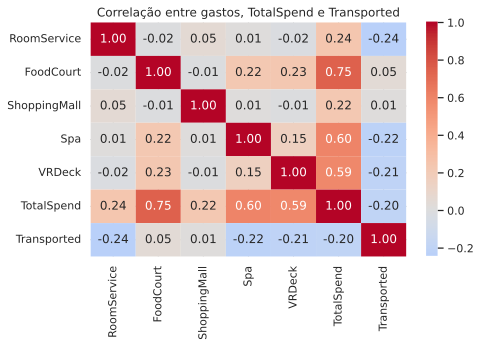

In [340]:
# Correlações entre gastos, TotalSpend e Transported
spend_corr_data = eda[spend_cols + ["TotalSpend", target]].copy()
spend_corr_data[target] = spend_corr_data[target].astype(int)
spend_corr = spend_corr_data.corr()

print("Correlação com Transported")
display(spend_corr[target].drop(target).sort_values(key=lambda values: values.abs(), ascending=False).to_frame("corr_com_target").round(3))

print("Correlação com TotalSpend")
display(spend_corr["TotalSpend"].drop("TotalSpend").sort_values(key=lambda values: values.abs(), ascending=False).to_frame("corr_com_total_spend").round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(spend_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlação entre gastos, TotalSpend e Transported")
plt.tight_layout()
plt.show()


**Leitura para o pré-processamento:** `TotalSpend` resume bem o comportamento geral de gasto e reduz cinco colunas para uma. Ainda assim, os serviços individuais não têm exatamente o mesmo sinal: `RoomService`, `Spa` e `VRDeck` aparecem mais negativos em relação ao alvo, enquanto `FoodCourt` e `ShoppingMall` são mais fracos. Para uma primeira modelagem mais simples, usaremos `TotalSpend` e removeremos os gastos individuais; depois vale comparar essa decisão por validação cruzada.


## 5. Relações lógicas entre CryoSleep e TotalSpend

`CryoSleep` tem uma relação lógica forte com gastos: passageiros em criossono não deveriam consumir serviços. Esta subseção verifica se a regra aparece nos dados e como ela se conecta ao alvo.


Resumo por CryoSleep


,CryoSleep,qtd_passageiros,taxa_transporte,mediana_total_spend,media_total_spend,pct_com_gasto,pct_com_gasto_ausente
0,False,5439,32.89,1019.0,2248.30,90.48,9.87
1,True,3037,81.76,0.0,0.00,0.00,11.43
2,NaN,217,48.85,703.0,1368.43,54.84,11.06


Resumo por CryoSleep e Transported


,CryoSleep,Transported,qtd_passageiros,mediana_total_spend,pct_com_gasto
0,False,False,3650,1057.0,94.55
1,False,True,1789,909.0,82.17
2,True,False,554,0.0,0.00
3,True,True,2483,0.0,0.00
4,NaN,False,111,1056.0,75.68
5,NaN,True,106,0.0,33.02


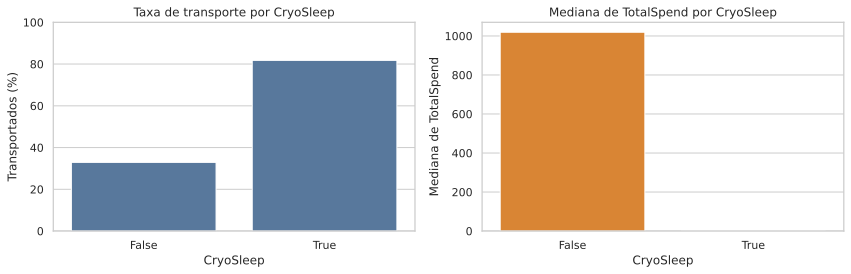

In [341]:
# Relação entre CryoSleep, TotalSpend, gasto positivo conhecido e Transported
cryo_summary = (
    eda.groupby("CryoSleep", dropna=False)
    .agg(
        qtd_passageiros=(target, "size"),
        taxa_transporte=(target, "mean"),
        mediana_total_spend=("TotalSpend", "median"),
        media_total_spend=("TotalSpend", "mean"),
        pct_com_gasto=("SpentSomething", "mean"),
        pct_com_gasto_ausente=("HasMissingSpend", "mean"),
    )
    .reset_index()
)

for col in ["taxa_transporte", "pct_com_gasto", "pct_com_gasto_ausente"]:
    cryo_summary[col] = (cryo_summary[col] * 100).round(2)

cryo_summary[["mediana_total_spend", "media_total_spend"]] = cryo_summary[
    ["mediana_total_spend", "media_total_spend"]
].round(2)

print("Resumo por CryoSleep")
display(cryo_summary)

print("Resumo por CryoSleep e Transported")
cryo_target_summary = (
    eda.groupby(["CryoSleep", target], dropna=False)
    .agg(
        qtd_passageiros=(target, "size"),
        mediana_total_spend=("TotalSpend", "median"),
        pct_com_gasto=("SpentSomething", "mean"),
    )
    .reset_index()
)
cryo_target_summary["pct_com_gasto"] = (cryo_target_summary["pct_com_gasto"] * 100).round(2)
display(cryo_target_summary)

plot_cryo_summary = cryo_summary.copy()
plot_cryo_summary["CryoSleep"] = plot_cryo_summary["CryoSleep"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=plot_cryo_summary, x="CryoSleep", y="taxa_transporte", ax=axes[0], color="#4C78A8")
axes[0].set_title("Taxa de transporte por CryoSleep")
axes[0].set_ylabel("Transportados (%)")
axes[0].set_xlabel("CryoSleep")
axes[0].set_ylim(0, 100)

sns.barplot(data=plot_cryo_summary, x="CryoSleep", y="mediana_total_spend", ax=axes[1], color="#F58518")
axes[1].set_title("Mediana de TotalSpend por CryoSleep")
axes[1].set_ylabel("Mediana de TotalSpend")
axes[1].set_xlabel("CryoSleep")

plt.tight_layout()
plt.show()


## 6. Relações lógicas entre PassengerGroup, FamilyName e HomePlanet

`PassengerGroup` vem do prefixo de `PassengerId`, enquanto `FamilyName` vem do sobrenome em `Name`. Esses atributos podem capturar relações familiares ou de viagem em grupo. Aqui avaliamos cardinalidade, tamanho dos grupos e o quanto esses grupos se alinham com `HomePlanet`.


Distribuição dos tamanhos de PassengerGroup


,qtd_grupos,qtd_passageiros,taxa_transporte_pct
PassengerGroupSize,,,
1,4805,4805,45.24
2,841,1682,53.80
3,340,1020,59.31
4,103,412,64.08
5,53,265,59.25
6,29,174,61.49
7,33,231,54.11
8,13,104,39.42


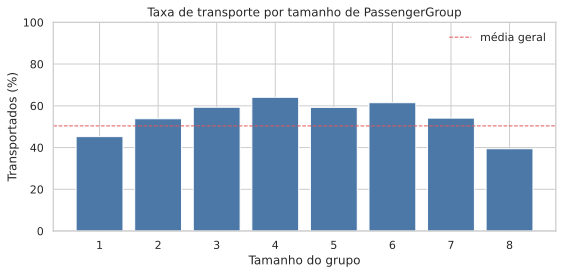

In [342]:
# Tamanho dos grupos de passageiros e taxa de transporte por tamanho
eda["PassengerGroupSize"] = eda.groupby("PassengerGroup")["PassengerGroup"].transform("size")

passenger_group_summary = (
    eda.groupby("PassengerGroupSize")
    .agg(
        qtd_grupos=("PassengerGroup", "nunique"),
        qtd_passageiros=("PassengerGroup", "size"),
        taxa_transporte=(target, "mean"),
    )
    .sort_index()
)
passenger_group_summary["taxa_transporte_pct"] = (passenger_group_summary["taxa_transporte"] * 100).round(2)
passenger_group_summary = passenger_group_summary.drop(columns="taxa_transporte")

print("Distribuição dos tamanhos de PassengerGroup")
display(passenger_group_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(passenger_group_summary.index.astype(str), passenger_group_summary["taxa_transporte_pct"], color="#4C78A8")
ax.axhline(eda[target].mean() * 100, color="#E45756", linestyle="--", linewidth=1, label="média geral")
ax.set_title("Taxa de transporte por tamanho de PassengerGroup")
ax.set_xlabel("Tamanho do grupo")
ax.set_ylabel("Transportados (%)")
ax.set_ylim(0, 100)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [343]:
# Cardinalidade e associação entre grupo, sobrenome e HomePlanet
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    contingency = pd.crosstab(x, y, dropna=False)
    chi2 = chi2_contingency(contingency, correction=False)[0]
    n = contingency.to_numpy().sum()
    r, k = contingency.shape
    denominator = n * min(r - 1, k - 1)
    if denominator == 0:
        return np.nan
    return np.sqrt(chi2 / denominator)

association_rows = []
for col in ["PassengerGroup", "FamilyName"]:
    homeplanet_counts = eda.groupby(col, dropna=False)["HomePlanet"].nunique(dropna=False)
    mixed = homeplanet_counts[homeplanet_counts > 1]
    association_rows.append(
        {
            "atributo": col,
            "cardinalidade": eda[col].nunique(dropna=True),
            "grupos_com_mais_de_um_homeplanet": mixed.size,
            "pct_grupos_mistos": mixed.size / homeplanet_counts.size * 100,
            "cramers_v_com_homeplanet": cramers_v(eda[col], eda["HomePlanet"]),
        }
    )

association_summary = pd.DataFrame(association_rows)
association_summary["pct_grupos_mistos"] = association_summary["pct_grupos_mistos"].round(2)
association_summary["cramers_v_com_homeplanet"] = association_summary["cramers_v_com_homeplanet"].round(4)

print("Associação entre PassengerGroup/FamilyName e HomePlanet")
display(association_summary)

family_summary = (
    eda.groupby("FamilyName", dropna=False)
    .agg(
        qtd_passageiros=(target, "size"),
        qtd_homeplanets=("HomePlanet", lambda values: values.nunique(dropna=False)),
        homeplanet_mais_frequente=("HomePlanet", lambda values: values.dropna().mode().iloc[0] if not values.dropna().mode().empty else np.nan),
        taxa_transporte=(target, "mean"),
    )
    .sort_values("qtd_passageiros", ascending=False)
)
family_summary["taxa_transporte_pct"] = (family_summary["taxa_transporte"] * 100).round(2)
family_summary = family_summary.drop(columns="taxa_transporte")

print("Sobrenomes mais frequentes")
display(family_summary.head(15))

print("Sobrenomes com pelo menos 5 passageiros e maiores taxas de transporte")
display(family_summary[family_summary["qtd_passageiros"] >= 5].sort_values("taxa_transporte_pct", ascending=False).head(15))


Associação entre PassengerGroup/FamilyName e HomePlanet


,atributo,cardinalidade,grupos_com_mais_de_um_homeplanet,pct_grupos_mistos,cramers_v_com_homeplanet
0,PassengerGroup,6217,89,1.43,0.9478
1,FamilyName,2217,182,8.21,0.8476


Sobrenomes mais frequentes


,qtd_passageiros,qtd_homeplanets,homeplanet_mais_frequente,taxa_transporte_pct
FamilyName,,,,
NaN,200,4,Earth,50.50
Casonston,18,1,Earth,38.89
Oneiles,16,1,Earth,37.50
Litthews,15,1,Earth,26.67
Domington,15,1,Earth,93.33
Fulloydez,14,1,Earth,42.86
Garnes,14,1,Earth,35.71
Cartez,14,1,Earth,50.00
Browlerson,14,1,Earth,64.29


Sobrenomes com pelo menos 5 passageiros e maiores taxas de transporte


,qtd_passageiros,qtd_homeplanets,homeplanet_mais_frequente,taxa_transporte_pct
FamilyName,,,,
Prie,6,1,Mars,100.0
Diateous,6,1,Europa,100.0
Drelcate,5,2,Europa,100.0
Connon,6,1,Earth,100.0
Carté,5,1,Mars,100.0
Holatirint,5,1,Europa,100.0
Ametic,6,1,Europa,100.0
Reenon,5,1,Earth,100.0
Stioutody,5,1,Europa,100.0


## 7. Avaliação de discretização do atributo idade

A idade é numérica, mas pode ter faixas com comportamento diferente em relação ao alvo. Vamos olhar uma discretização interpretável e, em seguida, testar vários limiares binários para ver onde uma árvore tenderia a separar melhor as classes pelo critério de impureza de Gini.


Taxa de transporte por faixa etária candidata


,qtd_passageiros,idade_mediana,taxa_transporte_pct
AgeGroupCandidate,,,
0-4,466,1.0,76.82
5-12,340,8.0,60.59
13-17,739,15.0,55.35
18-25,2351,21.0,45.81
26-35,2105,30.0,48.31
36-50,1776,41.0,48.65
51-65,653,56.0,48.55
66+,84,70.0,47.62


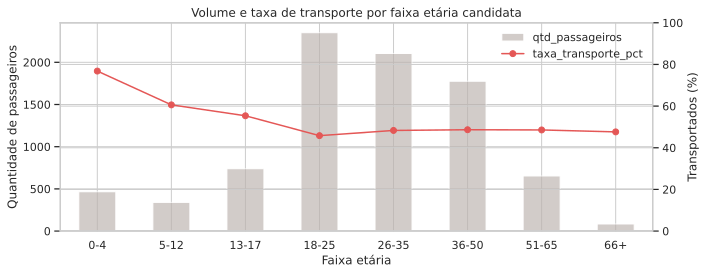

In [344]:
# Discretização candidata de idade e taxa de transporte por faixa
age_bins = [0, 4, 12, 17, 25, 35, 50, 65, np.inf]
age_labels = ["0-4", "5-12", "13-17", "18-25", "26-35", "36-50", "51-65", "66+"]

eda["AgeGroupCandidate"] = pd.cut(
    eda["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
)

age_group_summary = (
    eda.groupby("AgeGroupCandidate", observed=True)
    .agg(
        qtd_passageiros=(target, "size"),
        taxa_transporte=(target, "mean"),
        idade_mediana=("Age", "median"),
    )
)
age_group_summary["taxa_transporte_pct"] = (age_group_summary["taxa_transporte"] * 100).round(2)
age_group_summary = age_group_summary.drop(columns="taxa_transporte")

print("Taxa de transporte por faixa etária candidata")
display(age_group_summary)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

age_group_summary["qtd_passageiros"].plot(kind="bar", ax=ax1, color="#BAB0AC", alpha=0.65, label="qtd_passageiros")
age_group_summary["taxa_transporte_pct"].plot(kind="line", ax=ax2, color="#E45756", marker="o", label="taxa_transporte_pct")

ax1.set_title("Volume e taxa de transporte por faixa etária candidata")
ax1.set_xlabel("Faixa etária")
ax1.set_ylabel("Quantidade de passageiros")
ax2.set_ylabel("Transportados (%)")
ax2.set_ylim(0, 100)
ax1.tick_params(axis="x", rotation=0)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


Melhor limiar binário de idade pelo critério de Gini


,valor
threshold,4.000
weighted_gini,0.492
left_rate_pct,76.824
right_rate_pct,48.832
rate_diff_pct,27.992
left_count,466.000
right_count,8048.000


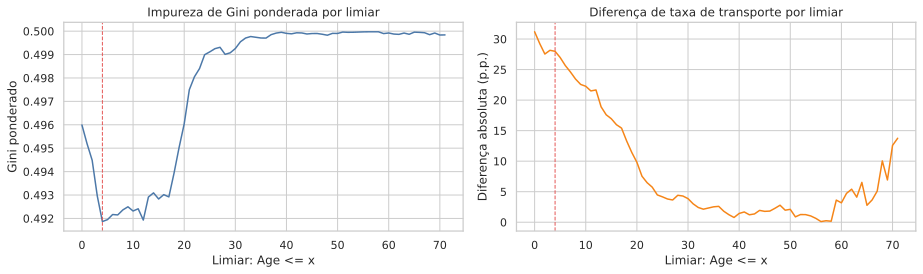

In [345]:
# Avaliação de limiares binários para discretização de Age
def gini_impurity(values):
    p = values.mean()
    return 1 - p**2 - (1 - p)**2

age_threshold_data = eda[["Age", target]].dropna().copy()
age_threshold_data[target] = age_threshold_data[target].astype(int)

threshold_rows = []
min_age = int(np.floor(age_threshold_data["Age"].min()))
max_age = int(np.ceil(age_threshold_data["Age"].max()))

for threshold in range(min_age, max_age):
    left = age_threshold_data.loc[age_threshold_data["Age"] <= threshold, target]
    right = age_threshold_data.loc[age_threshold_data["Age"] > threshold, target]

    if len(left) < 30 or len(right) < 30:
        continue

    weighted_gini = (len(left) * gini_impurity(left) + len(right) * gini_impurity(right)) / len(age_threshold_data)
    threshold_rows.append(
        {
            "threshold": threshold,
            "weighted_gini": weighted_gini,
            "left_rate_pct": left.mean() * 100,
            "right_rate_pct": right.mean() * 100,
            "rate_diff_pct": abs(left.mean() - right.mean()) * 100,
            "left_count": len(left),
            "right_count": len(right),
        }
    )

age_threshold_eval = pd.DataFrame(threshold_rows)
best_age_threshold = age_threshold_eval.sort_values("weighted_gini").iloc[0]

print("Melhor limiar binário de idade pelo critério de Gini")
display(best_age_threshold.to_frame("valor").round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(age_threshold_eval["threshold"], age_threshold_eval["weighted_gini"], color="#4C78A8")
axes[0].axvline(best_age_threshold["threshold"], color="#E45756", linestyle="--", linewidth=1)
axes[0].set_title("Impureza de Gini ponderada por limiar")
axes[0].set_xlabel("Limiar: Age <= x")
axes[0].set_ylabel("Gini ponderado")

axes[1].plot(age_threshold_eval["threshold"], age_threshold_eval["rate_diff_pct"], color="#F58518")
axes[1].axvline(best_age_threshold["threshold"], color="#E45756", linestyle="--", linewidth=1)
axes[1].set_title("Diferença de taxa de transporte por limiar")
axes[1].set_xlabel("Limiar: Age <= x")
axes[1].set_ylabel("Diferença absoluta (p.p.)")

plt.tight_layout()
plt.show()


## 8. Outras relações relevantes

Leitura conjunta de `CabinDeck` e `CabinSide`. Essa análise ajuda a decidir se faz sentido preservar essas duas variáveis categóricas no pré-processamento.


Taxa de transporte (%) por CabinDeck e CabinSide


CabinSide,P,S,NaN
CabinDeck,,,
A,43.59,54.68,NaN
B,67.42,78.40,NaN
C,58.06,76.35,NaN
D,40.32,46.52,NaN
E,34.27,37.14,NaN
F,41.10,47.05,NaN
G,44.83,58.38,NaN
T,25.00,0.00,NaN
NaN,NaN,NaN,50.25


Contagem de passageiros por CabinDeck e CabinSide


CabinSide,P,S,NaN
CabinDeck,,,
A,117.0,139.0,NaN
B,353.0,426.0,NaN
C,341.0,406.0,NaN
D,248.0,230.0,NaN
E,429.0,447.0,NaN
F,1438.0,1356.0,NaN
G,1276.0,1283.0,NaN
T,4.0,1.0,NaN
NaN,NaN,NaN,199.0


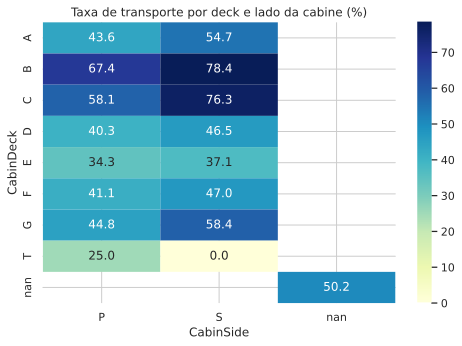

In [346]:
# Relação conjunta entre CabinDeck, CabinSide e Transported
cabin_pair_rate = eda.groupby(["CabinDeck", "CabinSide"], dropna=False)[target].mean().unstack().mul(100).round(2)
cabin_pair_count = eda.groupby(["CabinDeck", "CabinSide"], dropna=False)[target].size().unstack()

print("Taxa de transporte (%) por CabinDeck e CabinSide")
display(cabin_pair_rate)

print("Contagem de passageiros por CabinDeck e CabinSide")
display(cabin_pair_count)

plot_cabin_pair_rate = cabin_pair_rate.copy()
plot_cabin_pair_rate.index = plot_cabin_pair_rate.index.astype(str)
plot_cabin_pair_rate.columns = plot_cabin_pair_rate.columns.astype(str)

plt.figure(figsize=(7, 5))
sns.heatmap(plot_cabin_pair_rate, cmap="YlGnBu", annot=True, fmt=".1f")
plt.title("Taxa de transporte por deck e lado da cabine (%)")
plt.xlabel("CabinSide")
plt.ylabel("CabinDeck")
plt.tight_layout()
plt.show()


## Síntese da EDA

A partir dessa exploração reorganizada, os principais aprendizados são:

- O conjunto de treino tem 8693 registros e o alvo `Transported` está praticamente balanceado.
- Os valores ausentes são baixos, em torno de 2% por atributo, então a imputação deve ser importante, mas não domina o problema.
- `CryoSleep`, `HomePlanet`, `Destination`, `CabinDeck` e `CabinSide` mostram diferenças claras de taxa de transporte entre categorias.
- As colunas de gasto têm muitos zeros. `TotalSpend` é uma boa variável agregada para simplificar o pré-processamento, embora os gastos individuais ainda carreguem nuances diferentes.
- `CryoSleep=True` se conecta fortemente a `TotalSpend=0` e a uma taxa de transporte muito maior.
- `PassengerGroup` e `FamilyName` têm alta cardinalidade e se relacionam com `HomePlanet`; eles podem ajudar o modelo, mas pedem cuidado com overfitting.
- A idade sugere uma separação inicial forte em crianças pequenas, com limiares baixos aparecendo como bons candidatos de discretização.
- A relação conjunta entre `CabinDeck` e `CabinSide` reforça a decisão de manter ambas como variáveis categóricas no pré-processamento.


# Pré-processamento

Nesta seção, estruturamos o pré-processamento pensando em uma árvore de decisão com `Pipeline` do scikit-learn.

A função criada na EDA é reaproveitada para gerar `PassengerGroup`, `PassengerNum`, `CabinDeck`, `CabinSide`, `FamilyName` e `TotalSpend` de forma idêntica no treino e no teste. Com base na análise exploratória, removemos `CabinNum` e substituímos os gastos individuais por `TotalSpend`; `FamilyName` entra no One Hot Encoding junto com as demais variáveis categóricas.

Todo o ajuste é feito apenas no treino, evitando data leak ao transformar o conjunto de teste.


## Imputação de HomePlanet com PassengerGroup e FamilyName

Passo a passo usado no pipeline:

1. **PassengerGroup**: preenchemos `HomePlanet` pela moda do grupo de viagem.
2. **FamilyName**: se ainda faltar, preenchemos pela moda da família.
3. **Fallback KNN**: para o restante, usamos KNN com $k=5$ usando `HomePlanet` codificado e variáveis numéricas como referência.

In [347]:
# Conjunto base para modelagem
drop_cols = ["CabinNum"] + ["PassengerNum"]

train_model = split_cabin_passenger(train).drop(columns=drop_cols, errors="ignore")
test_model = split_cabin_passenger(test).drop(columns=drop_cols, errors="ignore")

target = "Transported"
X = train_model.drop(columns=[target])
y = train_model[target].astype(int)

print("Colunas usadas como entrada do modelo")
display(pd.DataFrame({"coluna": X.columns}))
print(X.head())

Colunas usadas como entrada do modelo


,coluna
0,HomePlanet
1,CryoSleep
2,Destination
3,Age
4,VIP
5,RoomService
6,FoodCourt
7,ShoppingMall
8,Spa
9,VRDeck


  HomePlanet CryoSleep  Destination   Age    VIP  RoomService  FoodCourt  \
0     Europa     False  TRAPPIST-1e  39.0  False          0.0        0.0   
1      Earth     False  TRAPPIST-1e  24.0  False        109.0        9.0   
2     Europa     False  TRAPPIST-1e  58.0   True         43.0     3576.0   
3     Europa     False  TRAPPIST-1e  33.0  False          0.0     1283.0   
4      Earth     False  TRAPPIST-1e  16.0  False        303.0       70.0   

   ShoppingMall     Spa  VRDeck PassengerGroup CabinDeck CabinSide  \
0           0.0     0.0     0.0           0001         B         P   
1          25.0   549.0    44.0           0002         F         S   
2           0.0  6715.0    49.0           0003         A         S   
3         371.0  3329.0   193.0           0003         A         S   
4         151.0   565.0     2.0           0004         F         S   

    FamilyName  TotalSpend  
0    Ofracculy         0.0  
1        Vines       736.0  
2       Susent     10383.0  
3     

## Legenda das variáveis binárias (0/1)

- `CabinSide`: P → 0, S → 1
- `CryoSleep`: False → 0, True → 1
- `VIP`: False → 0, True → 1

Além dessas transformações, aplicaremos One Hot Encoding em `CabinDeck`, `Destination`, `HomePlanet`, `PassengerGroup` e `FamilyName`. Os gastos individuais serão removidos nesta primeira versão do pré-processamento e representados por `TotalSpend`.


In [348]:
# Imputação hierárquica de HomePlanet com fallback KNN (k=5)
class HomePlanetImputer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        group_col="PassengerGroup",
        family_col="FamilyName",
        target_col="HomePlanet",
        knn_neighbors=5,
        knn_features=None
    ):
        self.group_col = group_col
        self.family_col = family_col
        self.target_col = target_col
        self.knn_neighbors = knn_neighbors
        self.knn_features = knn_features

    def _mode_or_nan(self, series):
        # Moda com desempate determinístico.
        values = series.dropna()
        if values.empty:
            return np.nan
        mode_values = values.mode()
        if mode_values.empty:
            return np.nan
        return mode_values.sort_values().iloc[0]

    def _apply_rule_based(self, df):
        homeplanet = df[self.target_col].copy()

        # Passo 1: preencher por PassengerGroup (moda do grupo).
        if self.group_col in df.columns:
            group_fill = df[self.group_col].map(self.group_mode_)
            homeplanet = homeplanet.fillna(group_fill)

        # Passo 2: preencher por FamilyName (moda da família).
        if self.family_col in df.columns:
            family_fill = df[self.family_col].map(self.family_mode_)
            homeplanet = homeplanet.fillna(family_fill)

        return homeplanet

    def _resolve_knn_features(self, df):
        # Seleciona variáveis numéricas para o KNN.
        if self.knn_features is not None:
            return [col for col in self.knn_features if col in df.columns]

        return [
            col
            for col in df.columns
            if col != self.target_col and pd.api.types.is_numeric_dtype(df[col])
        ]

    def _build_knn_frame(self, df, homeplanet_series):
        # Monta a matriz numérica usada no KNN.
        homeplanet_code = homeplanet_series.map(self.homeplanet_mapping_)
        knn_features = [col for col in self.knn_features_ if col in df.columns]
        feature_frame = df[knn_features].copy() if knn_features else pd.DataFrame(index=df.index)
        return pd.concat([homeplanet_code.rename("homeplanet_code"), feature_frame], axis=1)

    def fit(self, X, y=None):
        df = X.copy()

        # Ajusta mapas de moda por grupo e família.
        if self.group_col in df.columns:
            self.group_mode_ = df.groupby(self.group_col)[self.target_col].apply(self._mode_or_nan)
        else:
            self.group_mode_ = pd.Series(dtype=object)

        if self.family_col in df.columns:
            self.family_mode_ = df.groupby(self.family_col)[self.target_col].apply(self._mode_or_nan)
        else:
            self.family_mode_ = pd.Series(dtype=object)

        # Prepara o mapeamento numérico de HomePlanet.
        if self.target_col in df.columns:
            categories = df[self.target_col].dropna().unique().tolist()
        else:
            categories = []

        self.homeplanet_categories_ = sorted(categories)
        self.homeplanet_mapping_ = {
            value: idx for idx, value in enumerate(self.homeplanet_categories_)
        }

        self.knn_features_ = self._resolve_knn_features(df)
        self.knn_imputer_ = KNNImputer(n_neighbors=self.knn_neighbors)

        # Ajusta o KNN no treino para o fallback.
        homeplanet_rule = self._apply_rule_based(df)
        knn_frame = self._build_knn_frame(df, homeplanet_rule)
        self.knn_imputer_.fit(knn_frame)
        return self

    def transform(self, X):
        df = X.copy()

        if self.target_col not in df.columns:
            return df

        # Passo 1: PassengerGroup.
        homeplanet_original = df[self.target_col].copy()
        missing_original = homeplanet_original.isna()
        homeplanet_after_group = homeplanet_original.copy()

        if self.group_col in df.columns:
            group_fill = df[self.group_col].map(self.group_mode_)
            homeplanet_after_group = homeplanet_after_group.fillna(group_fill)

        group_imputed = missing_original & homeplanet_after_group.notna()

        # Passo 2: FamilyName (fallback).
        homeplanet_after_family = homeplanet_after_group.copy()
        if self.family_col in df.columns:
            family_fill = df[self.family_col].map(self.family_mode_)
            homeplanet_after_family = homeplanet_after_family.fillna(family_fill)

        family_imputed = homeplanet_after_group.isna() & homeplanet_after_family.notna()

        # Passo 3: fallback KNN.
        missing_for_knn = homeplanet_after_family.isna()
        homeplanet_final = homeplanet_after_family.copy()
        knn_imputed_count = 0

        if missing_for_knn.any() and self.homeplanet_categories_:
            knn_frame = self._build_knn_frame(df, homeplanet_after_family)
            imputed = self.knn_imputer_.transform(knn_frame)
            imputed_codes = imputed[:, 0]
            max_code = len(self.homeplanet_categories_) - 1
            imputed_codes = np.clip(np.rint(imputed_codes), 0, max_code).astype(int)
            imputed_labels = pd.Series(
                [self.homeplanet_categories_[code] for code in imputed_codes],
                index=df.index,
            )
            homeplanet_final = homeplanet_after_family.fillna(imputed_labels)

        df[self.target_col] = homeplanet_final
        return df

# Definição das colunas para o pré-processamento
categorical_ohe = ["CabinDeck", "Destination", "HomePlanet", "PassengerGroup", "FamilyName"]
binary_cols = ["CabinSide", "CryoSleep", "VIP"]

numeric_cols = [
    col
    for col in X.columns
    if col not in categorical_ohe + binary_cols
    and pd.api.types.is_numeric_dtype(X[col])
].copy()

# Imputador configurado para ser usado dentro do pipeline completo.
homeplanet_imputer = HomePlanetImputer(knn_neighbors=5)

binary_categories = [
    ["P", "S"],
    [False, True],
    [False, True],
]

def round_binary(values):
    return np.clip(np.rint(values), 0, 1).astype(int)

binary_pipeline = Pipeline(
    steps=[
        # Encoder: mapeia categorias binárias para 0/1 seguindo binary_categories.
        ("encoder", OrdinalEncoder(categories=binary_categories, handle_unknown="use_encoded_value", unknown_value=np.nan)),
        # Imputer: preenche valores ausentes após encoding, usando KNN para aproveitar similaridades entre passageiros.
        ("imputer", KNNImputer(n_neighbors=5)),
        # Rounder: após imputação via KNN, garante saída binária (0/1).
        ("rounder", FunctionTransformer(round_binary, feature_names_out="one-to-one")),
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler()),
    ]
)

# Mantemos a saída esparsa para reduzir memória com PassengerGroup e FamilyName.
categorical_pipeline = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("bin", binary_pipeline, binary_cols),
        ("cat", categorical_pipeline, categorical_ohe),
    ],
    remainder="drop",
)

# Modelos

Nesta etapa, treinamos e avaliamos uma árvore de decisão usando o `Pipeline` com o pré-processamento definido acima.

In [349]:
# Treinamento e avaliação com árvore de decisão (cross-validation)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

tree_model = DecisionTreeClassifier(random_state=42)
tree_pipeline = Pipeline(
    steps=[
        ("homeplanet_imputer", homeplanet_imputer),
        ("preprocess", preprocessor),
        ("model", tree_model),
    ]
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

cv_results = cross_validate(
    tree_pipeline,
    X,
    y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
)

cv_summary = pd.DataFrame({metric: cv_results[f"test_{metric}"] for metric in scoring})
print("Médias e desvios por métrica (10 folds)")
display(cv_summary.agg(["mean", "std"]).round(4))

Médias e desvios por métrica (10 folds)


,accuracy,precision,recall,f1
mean,0.7775,0.7775,0.7823,0.7798
std,0.0149,0.0158,0.0203,0.0154


In [350]:
# Treinamento final no treino completo e previsoes no teste (sem rotulos)
final_pipeline = Pipeline(
    steps=[
        ("homeplanet_imputer", homeplanet_imputer),
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]
)

final_pipeline.fit(X, y)

raw_test = pd.read_csv("./data/test.csv")
test_features = split_cabin_passenger(raw_test)
test_features = test_features.drop(columns=drop_cols, errors="ignore")

test_pred = final_pipeline.predict(test_features)

submission = pd.DataFrame(
    {
        "PassengerId": raw_test["PassengerId"],
        "Transported": test_pred.astype(bool),
    }
)

print("Previa do arquivo de submissao")
display(submission.head())

submission.to_csv("submission.csv", index=False)

Previa do arquivo de submissao


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


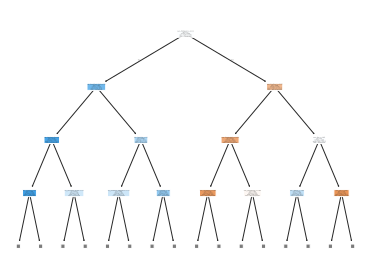

In [351]:
set_matplotlib_formats("svg")

tree.plot_tree(
    final_pipeline.named_steps["model"],
    feature_names=final_pipeline.named_steps["preprocess"].get_feature_names_out(),
    class_names=["Não transportado", "Transportado"],
    filled=True,
    max_depth=3,
 )
plt.show()

Matriz de confusao (holdout 20%)


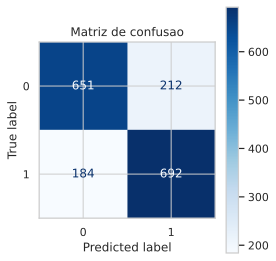

Curva ROC (holdout 20%)


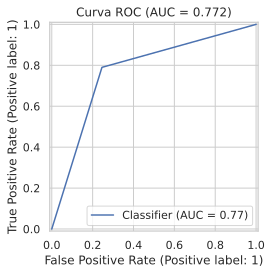

In [352]:
# Avaliacao em holdout para matriz de confusao e curva ROC
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

holdout_pipeline = Pipeline(
    steps=[
        ("homeplanet_imputer", homeplanet_imputer),
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]
)

holdout_pipeline.fit(X_train, y_train)

y_pred = holdout_pipeline.predict(X_val)

print("Matriz de confusao (holdout 20%)")
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=ax, cmap="Blues")
ax.set_title("Matriz de confusao")
plt.tight_layout()
plt.show()

y_score = holdout_pipeline.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_score)

print("Curva ROC (holdout 20%)")
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_val, y_score, ax=ax)
ax.set_title(f"Curva ROC (AUC = {auc:.3f})")
plt.tight_layout()
plt.show()